<a href="https://colab.research.google.com/github/San-lab-ship/Prediccion-Flujo-Pasajeros-Aeropuertos/blob/main/Predicci%C3%B3n_del_Flujo_de_Pasajeros_en_Aeropuertos_con_Machine_Learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install xgboost


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

sns.set_style("whitegrid")


In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

df.columns = ["Date","Passengers"]

df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df.head()


,Date,Passengers,Year,Month
0,1949-01-01,112,1949,1
1,1949-02-01,118,1949,2
2,1949-03-01,132,1949,3
3,1949-04-01,129,1949,4
4,1949-05-01,121,1949,5


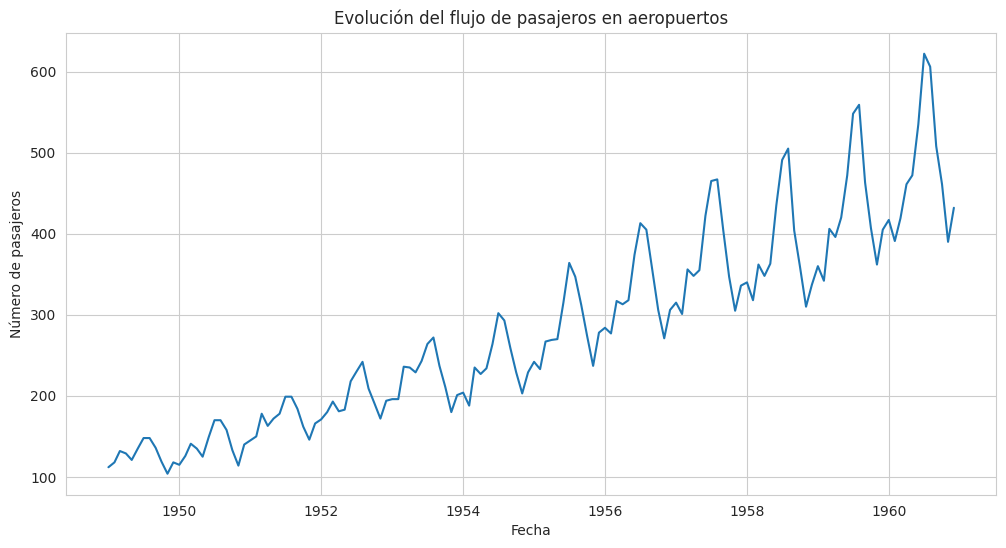

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Passengers"])

plt.title("Evolución del flujo de pasajeros en aeropuertos")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")

plt.show()


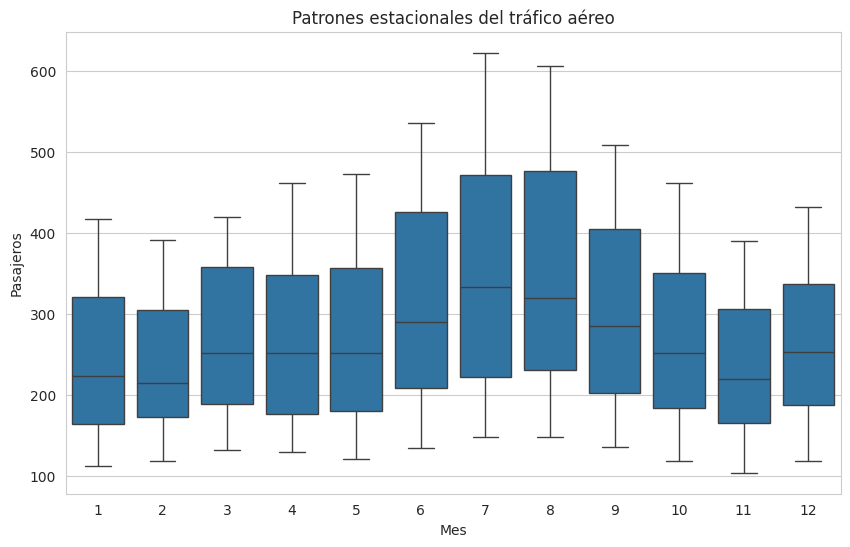

In [6]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Month", y="Passengers", data=df)

plt.title("Patrones estacionales del tráfico aéreo")
plt.xlabel("Mes")
plt.ylabel("Pasajeros")

plt.show()


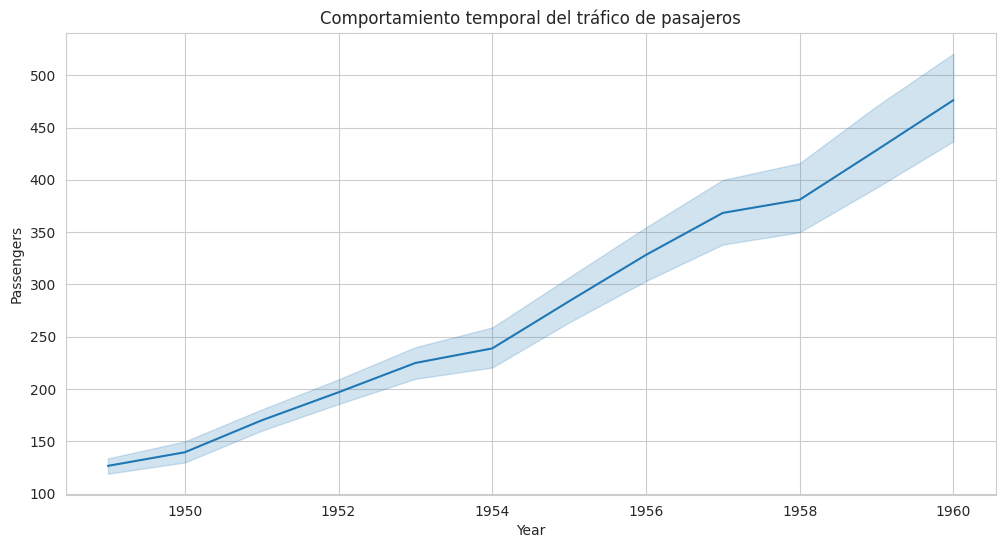

In [7]:
plt.figure(figsize=(12,6))

sns.lineplot(x="Year", y="Passengers", data=df)

plt.title("Comportamiento temporal del tráfico de pasajeros")

plt.show()


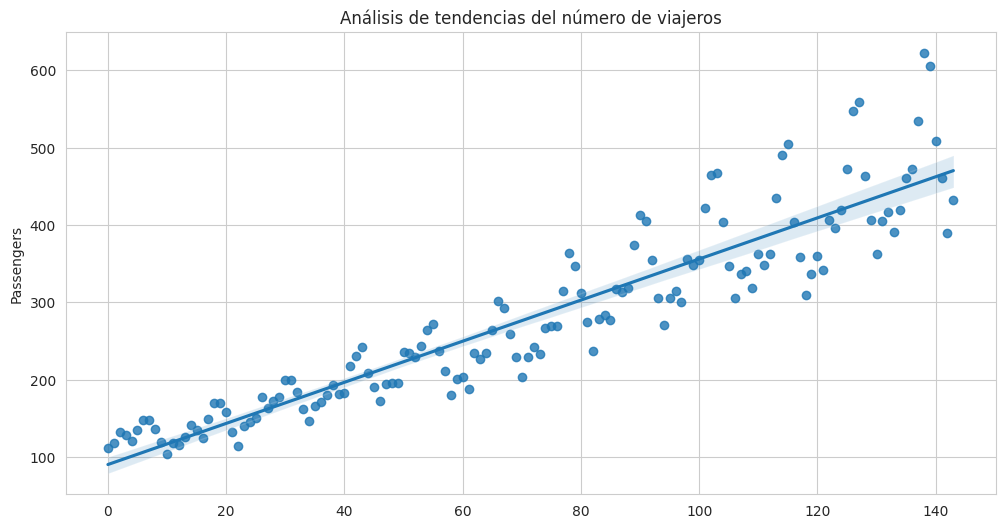

In [8]:
plt.figure(figsize=(12,6))

sns.regplot(x=np.arange(len(df)), y=df["Passengers"])

plt.title("Análisis de tendencias del número de viajeros")

plt.show()


In [10]:
X = df[["Year","Month"]]
y = df["Passengers"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)


In [11]:
rf_model = RandomForestRegressor()

rf_model.fit(X_train,y_train)

rf_pred = rf_model.predict(X_test)


In [12]:
xgb_model = XGBRegressor()

xgb_model.fit(X_train,y_train)

xgb_pred = xgb_model.predict(X_test)


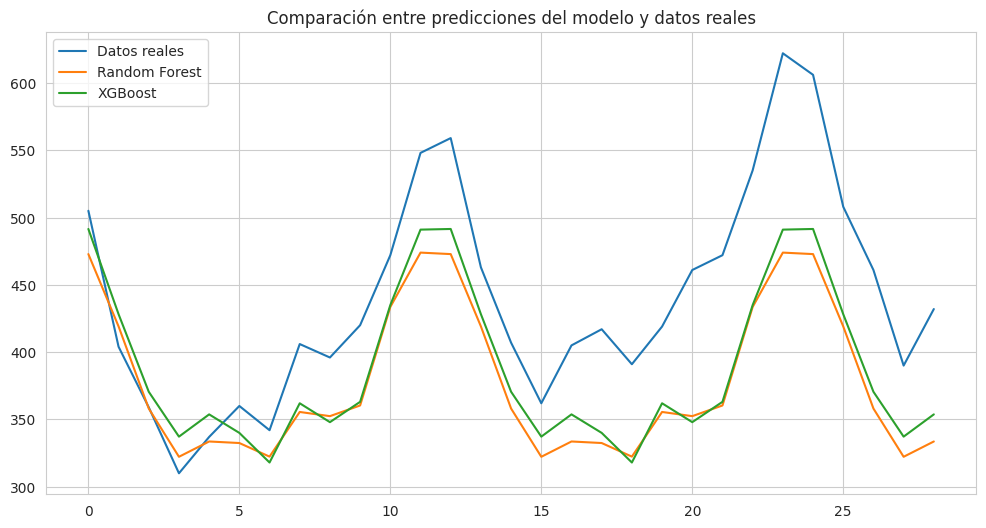

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Datos reales")
plt.plot(rf_pred, label="Random Forest")
plt.plot(xgb_pred, label="XGBoost")

plt.title("Comparación entre predicciones del modelo y datos reales")

plt.legend()

plt.show()


In [14]:
def metrics(y_true,y_pred):

    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae = mean_absolute_error(y_true,y_pred)
    r2 = r2_score(y_true,y_pred)

    return rmse,mae,r2


print("Random Forest:",metrics(y_test,rf_pred))
print("XGBoost:",metrics(y_test,xgb_pred))


Random Forest: (np.float64(73.99745610725294), 63.60965517241379, 0.1030170241353705)
XGBoost: (np.float64(66.49746676330986), 57.615455627441406, 0.2756294012069702)


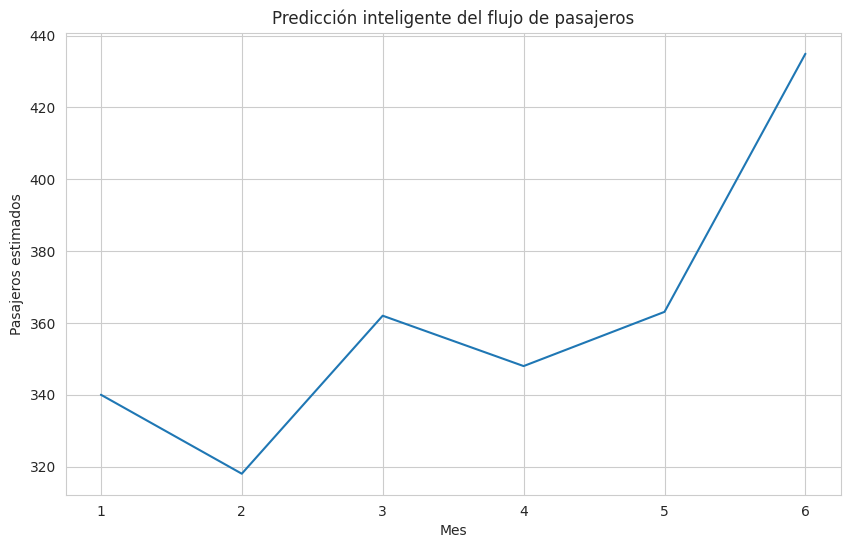

In [15]:
future = pd.DataFrame({

"Year":[1961,1961,1961,1961,1961,1961],
"Month":[1,2,3,4,5,6]

})

future_pred = xgb_model.predict(future)

plt.figure(figsize=(10,6))

plt.plot(future["Month"],future_pred)

plt.title("Predicción inteligente del flujo de pasajeros")

plt.xlabel("Mes")
plt.ylabel("Pasajeros estimados")

plt.show()


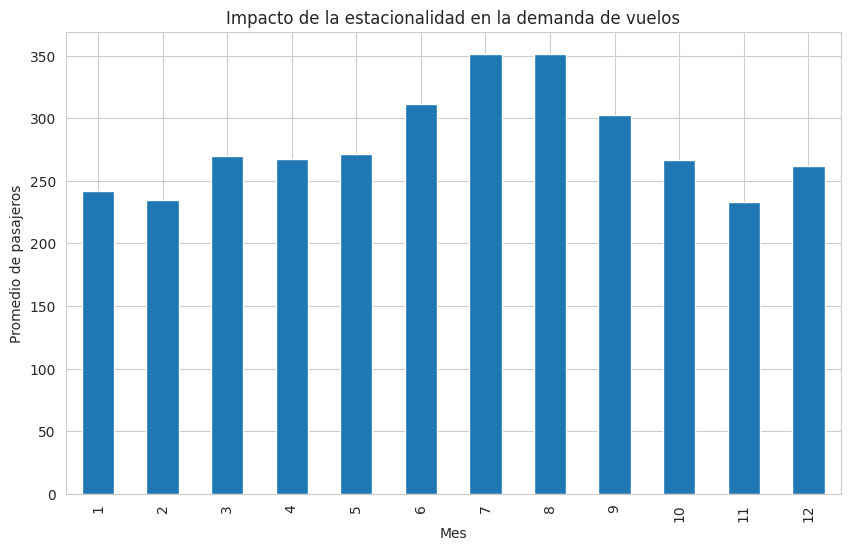

In [16]:
monthly_avg = df.groupby("Month")["Passengers"].mean()

plt.figure(figsize=(10,6))

monthly_avg.plot(kind="bar")

plt.title("Impacto de la estacionalidad en la demanda de vuelos")

plt.xlabel("Mes")
plt.ylabel("Promedio de pasajeros")

plt.show()
